# Prophet Pipeline: Role Demand Forecasting

End-to-end pipeline for role-level job demand forecasting using Prophet.

Workflow:
1. Load and validate dataset
2. Preprocess and normalize schema
3. EDA and visualization
4. Feature engineering
5. Training and cross-validation
6. Evaluation and ranking
7. Save artifacts
8. Compare with ARIMA results (if available)

In [1]:
# Install and import dependencies
try:
    from prophet import Prophet
except Exception:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'prophet', '-q'])
    from prophet import Prophet

from pathlib import Path
import json
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')

In [2]:
# Configuration and paths
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'Job_pipeline').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / 'Job_pipeline' / 'data' / 'processed' / 'afriwork_all_jobs_20260310_124628.csv'

OUTPUT_ROOT = PROJECT_ROOT / 'model' / 'timeseries' / 'artifacts'
MODEL_NAME = 'prophet'
MODEL_DIR = OUTPUT_ROOT / 'models' / MODEL_NAME
FORECAST_DIR = OUTPUT_ROOT / 'forecasts'
METRIC_DIR = OUTPUT_ROOT / 'metrics'
PLOT_DIR = OUTPUT_ROOT / 'plots' / MODEL_NAME

for folder in [MODEL_DIR, FORECAST_DIR, METRIC_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data path: {DATA_PATH}')

Project root: c:\Users\user\Desktop\5th\VentureScope\Data-ML
Data path: c:\Users\user\Desktop\5th\VentureScope\Data-ML\Job_pipeline\data\processed\afriwork_all_jobs_20260310_124628.csv


In [3]:
# Load dataset and normalize schema
raw_df = pd.read_csv(DATA_PATH)
print('Raw shape:', raw_df.shape)

required_columns = {'normalized_title', 'job_id'}
missing_required = required_columns.difference(raw_df.columns)
if missing_required:
    raise ValueError(f'Missing required columns: {sorted(missing_required)}')

date_source_col = None
for candidate in ['timestamp', 'year_month', 'month']:
    if candidate in raw_df.columns:
        date_source_col = candidate
        break
if date_source_col is None:
    raise ValueError("Expected one of date columns: ['timestamp', 'year_month', 'month']")

df = raw_df.copy()
df['event_date'] = pd.to_datetime(df[date_source_col], errors='coerce')
df['role'] = df['normalized_title'].astype(str).str.strip()

before_dedup = len(df)
df = df.drop_duplicates(subset=['job_id'])

df = df.dropna(subset=['event_date', 'role']).copy()
df = df[df['role'] != '']

# Optional typed signals
if 'holiday_flag' in df.columns:
    df['holiday_flag'] = pd.to_numeric(df['holiday_flag'], errors='coerce').fillna(0).clip(0, 1)
if 'is_remote' in df.columns:
    df['is_remote_num'] = (
        df['is_remote'].astype(str).str.lower().isin(['1', 'true', 'yes', 'remote']).astype(float)
    )

print('Date source:', date_source_col)
print('Removed duplicates:', before_dedup - len(df))
print('Cleaned shape:', df.shape)
df[['job_id', 'normalized_title', 'role', 'event_date']].head()

Raw shape: (3105, 15)
Date source: timestamp
Removed duplicates: 541
Cleaned shape: (2564, 18)


,job_id,normalized_title,role,event_date
0,db7e5f29ad8acd4b,Frontend Developer,Frontend Developer,2023-05-02 12:21:08.391921+00:00
1,2fde0601f1cd3954,Mobile Developer,Mobile Developer,2026-03-09 13:12:52.043397+00:00
2,3916c66c1af1e2ab,Data Analyst,Data Analyst,2026-03-09 08:07:18.877749+00:00
3,a3cdc14490e42844,UI/UX Designer,UI/UX Designer,2026-03-07 10:13:36.992229+00:00
4,cfec2ff86e6c086c,Other,Other,2026-03-06 20:44:53.344375+00:00


## EDA and Visualization
Quick checks for volume, role distribution, and monthly trend structure.

In [4]:
# EDA summary
print('Columns:', sorted(df.columns.tolist()))
print('Unique roles:', df['role'].nunique())
print('Date range:', df['event_date'].min(), 'to', df['event_date'].max())

monthly_total = (
    df.assign(month=df['event_date'].dt.to_period('M').dt.to_timestamp())
      .groupby('month', as_index=False)
      .size()
      .rename(columns={'size': 'job_count'})
)

top_roles = df['role'].value_counts().head(15)
display(monthly_total.head())
display(top_roles.to_frame('posting_count'))

Columns: ['DescriptionVec', 'city', 'country', 'education_level', 'event_date', 'holiday_flag', 'is_remote', 'is_remote_num', 'job_id', 'job_title', 'job_type', 'month', 'normalized_title', 'region', 'role', 'skills', 'timestamp', 'year_month']
Unique roles: 22
Date range: 2022-08-14 17:47:38.768705+00:00 to 2026-03-09 13:12:52.043397+00:00


,month,job_count
0,2022-08-01,1
1,2022-09-01,2
2,2022-10-01,24
3,2022-11-01,21
4,2022-12-01,48


,posting_count
role,
Frontend Developer,294
Full Stack Developer,290
UI/UX Designer,285
Mobile Developer,273
Product Manager,268
Software Engineer,238
Backend Developer,221
Other,170
Data Analyst,84


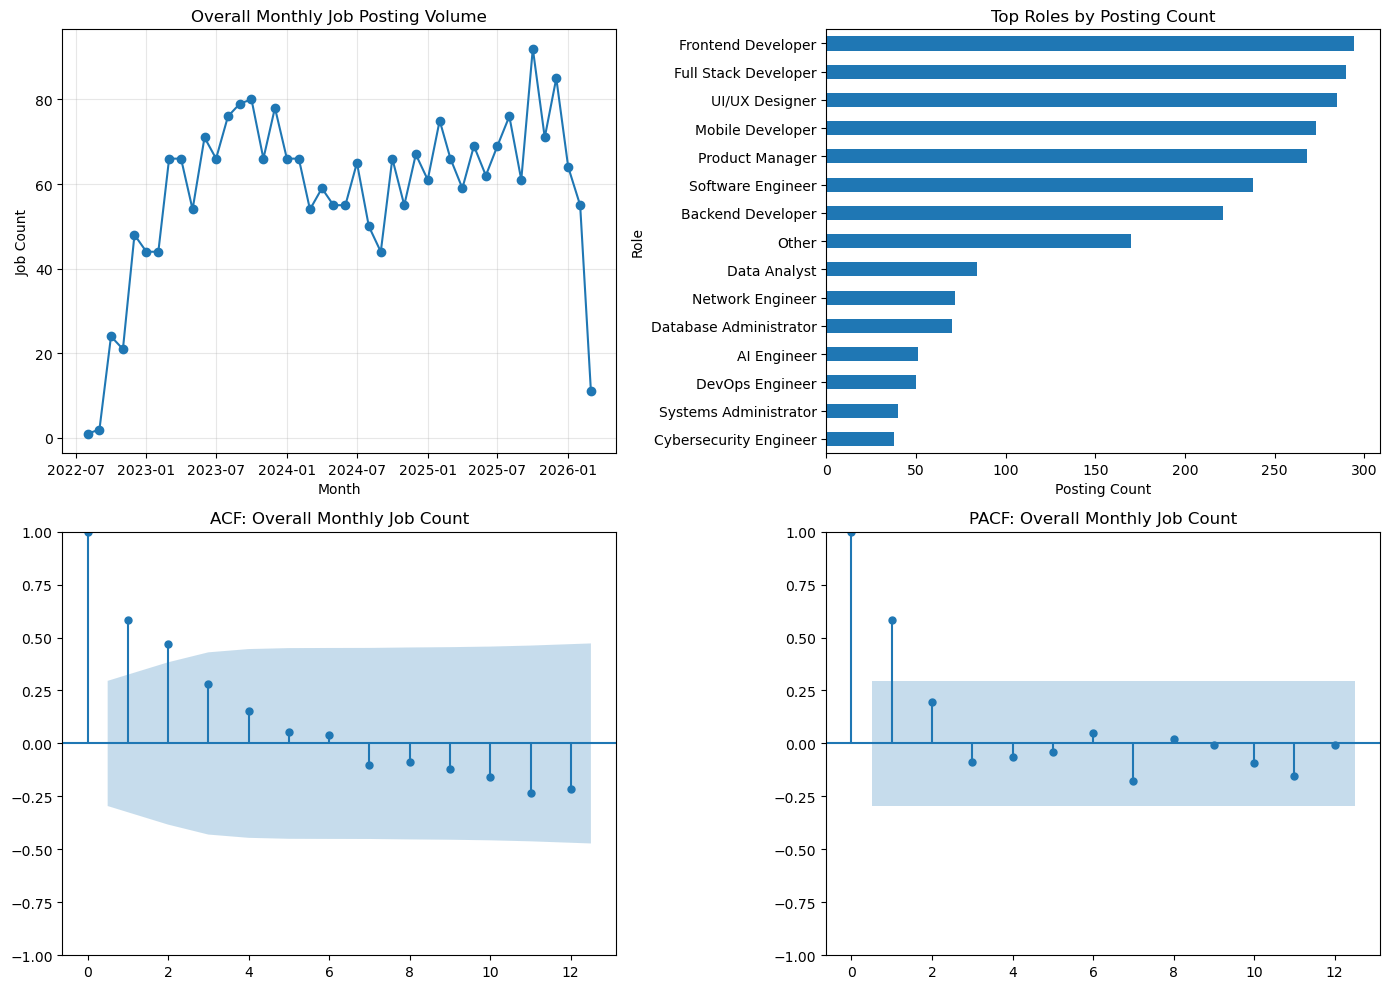

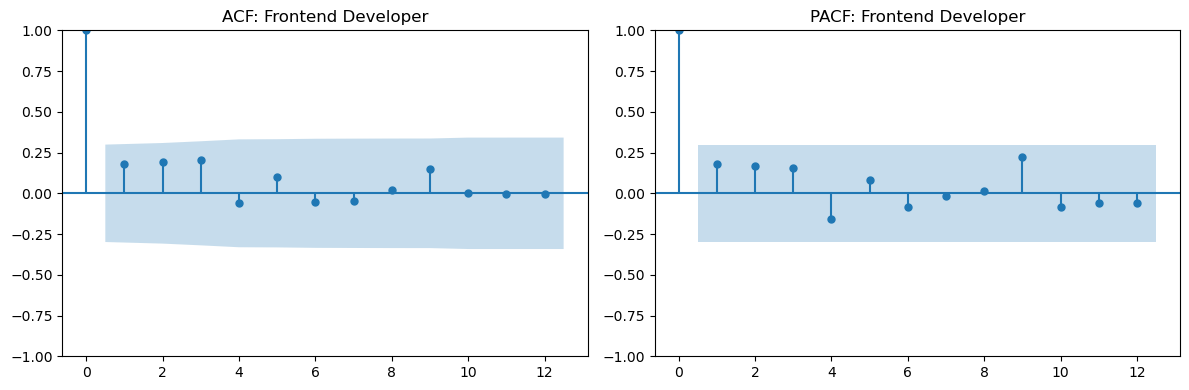

In [5]:
# Visualization + ACF/PACF
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(monthly_total['month'], monthly_total['job_count'], marker='o')
axes[0, 0].set_title('Overall Monthly Job Posting Volume')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Job Count')
axes[0, 0].grid(alpha=0.3)

top_roles.sort_values().plot(kind='barh', ax=axes[0, 1])
axes[0, 1].set_title('Top Roles by Posting Count')
axes[0, 1].set_xlabel('Posting Count')
axes[0, 1].set_ylabel('Role')

overall_series = monthly_total['job_count'].astype(float).values
max_lags = min(12, max(1, len(overall_series) // 2 - 1))
plot_acf(overall_series, lags=max_lags, ax=axes[1, 0])
axes[1, 0].set_title('ACF: Overall Monthly Job Count')

if len(overall_series) >= 3:
    pacf_lags = min(max_lags, len(overall_series) // 2 - 1)
    if pacf_lags >= 1:
        plot_pacf(overall_series, lags=pacf_lags, ax=axes[1, 1], method='ywm')
        axes[1, 1].set_title('PACF: Overall Monthly Job Count')
    else:
        axes[1, 1].text(0.5, 0.5, 'Not enough data for PACF', ha='center', va='center')
        axes[1, 1].set_title('PACF: Overall Monthly Job Count')
else:
    axes[1, 1].text(0.5, 0.5, 'Not enough data for PACF', ha='center', va='center')
    axes[1, 1].set_title('PACF: Overall Monthly Job Count')

plt.tight_layout()
plt.show()

# ACF/PACF for the single highest-volume role
top_role_name = top_roles.index[0] if len(top_roles) else None
if top_role_name is not None:
    role_series = (
        df[df['role'] == top_role_name]
        .assign(month=df['event_date'].dt.to_period('M').dt.to_timestamp())
        .groupby('month', as_index=False)
        .size()
        .rename(columns={'size': 'job_count'})
        .sort_values('month')['job_count']
        .astype(float)
        .values
    )
    role_lags = min(12, max(1, len(role_series) // 2 - 1))
    fig, ax2 = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(role_series, lags=role_lags, ax=ax2[0])
    ax2[0].set_title(f'ACF: {top_role_name}')
    if len(role_series) >= 3 and role_lags >= 1:
        plot_pacf(role_series, lags=role_lags, ax=ax2[1], method='ywm')
        ax2[1].set_title(f'PACF: {top_role_name}')
    else:
        ax2[1].text(0.5, 0.5, 'Not enough data for PACF', ha='center', va='center')
        ax2[1].set_title(f'PACF: {top_role_name}')
    plt.tight_layout()
    plt.show()

## Feature Engineering
Create a monthly panel per role and engineered features for forecasting.

In [6]:
# Monthly aggregation with engineered regressors
df['month'] = df['event_date'].dt.to_period('M').dt.to_timestamp()

agg_ops = {'job_id': 'count'}
if 'holiday_flag' in df.columns:
    agg_ops['holiday_flag'] = 'mean'
if 'is_remote_num' in df.columns:
    agg_ops['is_remote_num'] = 'mean'

monthly_role = df.groupby(['role', 'month'], as_index=False).agg(agg_ops)
monthly_role = monthly_role.rename(columns={'job_id': 'job_count', 'holiday_flag': 'holiday_rate', 'is_remote_num': 'remote_rate'})

month_index = pd.date_range(monthly_role['month'].min(), monthly_role['month'].max(), freq='MS')
expanded_frames = []
for role_name, role_df in monthly_role.groupby('role'):
    role_df = role_df.set_index('month').reindex(month_index).rename_axis('month').reset_index()
    role_df['role'] = role_name
    role_df['job_count'] = role_df['job_count'].fillna(0)
    for col in ['holiday_rate', 'remote_rate']:
        if col in role_df.columns:
            role_df[col] = role_df[col].ffill().bfill().fillna(0)
    expanded_frames.append(role_df)

modeling_df = pd.concat(expanded_frames, ignore_index=True)
modeling_df = modeling_df.sort_values(['role', 'month']).reset_index(drop=True)

# Required shape for modeling input
final_modeling_view = modeling_df[['month', 'role', 'job_count']].copy()
print('Modeling shape:', final_modeling_view.shape)
display(final_modeling_view.head())

Modeling shape: (968, 3)


,month,role,job_count
0,2022-08-01,AI Engineer,0.0
1,2022-09-01,AI Engineer,0.0
2,2022-10-01,AI Engineer,0.0
3,2022-11-01,AI Engineer,0.0
4,2022-12-01,AI Engineer,0.0


In [7]:
# Role selection for robust CV runtime
min_months = 8
max_roles = 30
role_stats = modeling_df.groupby('role', as_index=False).agg(
    total_jobs=('job_count', 'sum'),
    n_months=('month', 'nunique')
)
eligible_roles = (
    role_stats[role_stats['n_months'] >= min_months]
    .sort_values('total_jobs', ascending=False)
    .head(max_roles)['role']
    .tolist()
)

print('Eligible roles:', len(eligible_roles))
display(role_stats.sort_values('total_jobs', ascending=False).head(10))

Eligible roles: 22


,role,total_jobs,n_months
9,Frontend Developer,294.0,44
10,Full Stack Developer,290.0,44
21,UI/UX Designer,285.0,44
13,Mobile Developer,273.0,44
16,Product Manager,268.0,44
19,Software Engineer,238.0,44
1,Backend Developer,221.0,44
15,Other,170.0,44
4,Data Analyst,84.0,44
14,Network Engineer,72.0,44


## Training, Cross-Validation, and Forecasting
Train Prophet per role, run time-series CV, and forecast 6 months.

In [8]:
horizon_months = 6
cv_horizon_months = 3
holdout_months = 3

prophet_models = {}
prophet_forecasts = {}
evaluation_rows = []
prediction_rows = []

for role_name in eligible_roles:
    role_df = modeling_df[modeling_df['role'] == role_name].copy()
    role_df = role_df.sort_values('month')

    full_df = role_df.rename(columns={'month': 'ds', 'job_count': 'y'})[['ds', 'y']].copy()
    regressor_cols = [c for c in ['holiday_rate', 'remote_rate'] if c in role_df.columns]
    for col in regressor_cols:
        full_df[col] = role_df[col].values

    if len(full_df) < 8:
        continue

    # Holdout backtest setup
    if len(full_df) > holdout_months + 4:
        train_back = full_df.iloc[:-holdout_months].copy()
        test_back = full_df.iloc[-holdout_months:].copy()
    else:
        train_back = full_df.copy()
        test_back = pd.DataFrame(columns=full_df.columns)

    # Fit model on backtest train for holdout metrics
    back_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for col in regressor_cols:
        back_model.add_regressor(col)
    back_model.fit(train_back)

    holdout_rmse = np.nan
    holdout_mae = np.nan
    holdout_naive_rmse = np.nan
    holdout_naive_mae = np.nan
    holdout_rmse_improvement_pct = np.nan
    holdout_mae_improvement_pct = np.nan

    if not test_back.empty:
        future_back = back_model.make_future_dataframe(periods=len(test_back), freq='MS')
        for col in regressor_cols:
            future_back[col] = train_back[col].iloc[-1]
        pred_back = back_model.predict(future_back).tail(len(test_back))
        y_true = test_back['y'].values.astype(float)
        y_pred = pred_back['yhat'].values.astype(float)

        holdout_rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        holdout_mae = float(mean_absolute_error(y_true, y_pred))

        naive_pred = np.repeat(train_back['y'].iloc[-1], len(test_back)).astype(float)
        holdout_naive_rmse = float(np.sqrt(mean_squared_error(y_true, naive_pred)))
        holdout_naive_mae = float(mean_absolute_error(y_true, naive_pred))

        if holdout_naive_rmse > 0:
            holdout_rmse_improvement_pct = float((holdout_naive_rmse - holdout_rmse) / holdout_naive_rmse * 100.0)
        if holdout_naive_mae > 0:
            holdout_mae_improvement_pct = float((holdout_naive_mae - holdout_mae) / holdout_naive_mae * 100.0)

    # Fit final model on full history for production forecast
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for col in regressor_cols:
        model.add_regressor(col)
    model.fit(full_df)

    # Prophet rolling CV
    cv_rmse = np.nan
    cv_mae = np.nan
    cv_mape = np.nan
    cv_rows = 0
    cv_note = ''

    try:
        cv_df = cross_validation(
            model,
            initial='240 days',
            period='60 days',
            horizon=f'{cv_horizon_months * 30} days',
            parallel='processes'
        )
        pm = performance_metrics(cv_df)
        cv_rmse = float(pm['rmse'].mean())
        cv_mae = float(pm['mae'].mean())
        cv_mape = float(pm['mape'].mean()) if 'mape' in pm.columns else np.nan
        cv_rows = int(len(cv_df))
    except Exception as exc:
        cv_note = str(exc)

    evaluation_rows.append({
        'role': role_name,
        'model': 'prophet',
        'cv_rmse': cv_rmse,
        'cv_mae': cv_mae,
        'cv_mape': cv_mape,
        'cv_rows': cv_rows,
        'holdout_rmse': holdout_rmse,
        'holdout_mae': holdout_mae,
        'holdout_naive_rmse': holdout_naive_rmse,
        'holdout_naive_mae': holdout_naive_mae,
        'holdout_rmse_improvement_pct': holdout_rmse_improvement_pct,
        'holdout_mae_improvement_pct': holdout_mae_improvement_pct,
        'note': cv_note
    })

    # Future regressors: carry forward last observed values
    future = model.make_future_dataframe(periods=horizon_months, freq='MS')
    for col in regressor_cols:
        future[col] = full_df[col].iloc[-1]

    fcst = model.predict(future)
    prophet_models[role_name] = model
    prophet_forecasts[role_name] = fcst

    next_6 = fcst.tail(horizon_months)
    prediction_rows.append({
        'role': role_name,
        'model': 'prophet',
        'pred_next_6m_sum': float(next_6['yhat'].sum()),
        'pred_next_6m_mean': float(next_6['yhat'].mean())
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values(
    ['holdout_rmse', 'cv_rmse'], na_position='last'
)
predictions_df = pd.DataFrame(prediction_rows).sort_values('pred_next_6m_sum', ascending=False)

print('Trained Prophet roles:', len(prophet_models))
display(evaluation_df.head(10))
display(predictions_df.head(10))

03:38:56 - cmdstanpy - INFO - Chain [1] start processing
03:38:57 - cmdstanpy - INFO - Chain [1] done processing
03:38:58 - cmdstanpy - INFO - Chain [1] start processing
03:38:58 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
03:39:53 - cmdstanpy - INFO - Chain [1] start processing
03:39:54 - cmdstanpy - INFO - Chain [1] done processing
03:39:54 - cmdstanpy - INFO - Chain [1] start processing
03:39:55 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
03:41:08 - cmdstanpy - INFO - Chain [1] start processing
03:41:08 - cmdstanpy - INFO - Chain [1] done processing
03:41:09 - cmdstanpy - INFO - Chain [1] start processing
03:41:10 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
03:42:44 -

Trained Prophet roles: 22


,role,model,cv_rmse,cv_mae,cv_mape,cv_rows,holdout_rmse,holdout_mae,holdout_naive_rmse,holdout_naive_mae,holdout_rmse_improvement_pct,holdout_mae_improvement_pct,note
21,Embedded Systems Engineer,prophet,0.065303,0.030576,NaN,50,0.070325,0.069839,1.000000,1.000000,92.967493,93.016084,
19,Cloud Engineer,prophet,2.932857,1.847001,NaN,50,0.154401,0.143037,0.000000,0.000000,NaN,NaN,
20,MLOps Engineer,prophet,0.698758,0.473486,NaN,50,0.195931,0.195283,0.000000,0.000000,NaN,NaN,
18,Machine Learning Engineer,prophet,2.754533,1.932953,NaN,50,0.418129,0.393929,0.000000,0.000000,NaN,NaN,
15,QA Engineer,prophet,4.069468,2.737399,NaN,50,0.671154,0.483160,0.816497,0.666667,17.800717,27.525982,
17,Data Scientist,prophet,2.929696,2.020963,NaN,50,0.972476,0.933818,1.732051,1.666667,43.854079,43.970935,
16,Site Reliability Engineer,prophet,1.842121,1.389020,NaN,50,1.409265,1.339969,1.000000,1.000000,-40.926515,-33.996889,
11,AI Engineer,prophet,4.213667,2.790703,NaN,50,1.461498,1.438900,1.732051,1.666667,15.620376,13.666002,
8,Data Analyst,prophet,5.828327,4.472512,NaN,50,1.597863,1.553495,1.414214,1.333333,-12.986003,-16.512146,
14,Cybersecurity Engineer,prophet,5.803944,3.847117,NaN,50,1.865805,1.839116,2.000000,2.000000,6.709736,8.044205,


,role,model,pred_next_6m_sum,pred_next_6m_mean
1,Full Stack Developer,prophet,65.582500,10.930417
2,UI/UX Designer,prophet,48.447459,8.074576
6,Backend Developer,prophet,46.467604,7.744601
4,Product Manager,prophet,44.972126,7.495354
3,Mobile Developer,prophet,31.585938,5.264323
5,Software Engineer,prophet,24.366030,4.061005
0,Frontend Developer,prophet,22.627977,3.771330
9,Network Engineer,prophet,12.876031,2.146005
16,Site Reliability Engineer,prophet,12.653674,2.108946
7,Other,prophet,12.109194,2.018199


## Evaluation Interpretation
- cv_rmse / cv_mae: rolling-origin Prophet CV error across multiple historical cutoffs.
- holdout_rmse / holdout_mae: strict last-window backtest error on unseen final months.
- holdout_naive_*: baseline that predicts all holdout months using the last train value.
- holdout_*_improvement_pct:
  - Positive value means Prophet beat the naive baseline.
  - Negative value means naive baseline performed better.

In [9]:
# Diagnostics ranking: prioritize reliable holdout performance
if not evaluation_df.empty:
    diag_cols = [
        'role', 'cv_rmse', 'cv_mae',
        'holdout_rmse', 'holdout_mae',
        'holdout_naive_rmse', 'holdout_naive_mae',
        'holdout_rmse_improvement_pct', 'holdout_mae_improvement_pct'
    ]
    diagnostics_df = evaluation_df[diag_cols].copy()
    diagnostics_df = diagnostics_df.sort_values(
        ['holdout_rmse', 'cv_rmse'], na_position='last'
    ).reset_index(drop=True)
    display(diagnostics_df.head(15))

    good_roles = diagnostics_df[
        (diagnostics_df['holdout_rmse_improvement_pct'] > 0) &
        (diagnostics_df['holdout_mae_improvement_pct'] > 0)
    ]
    print(f'Roles beating naive baseline on both RMSE and MAE: {len(good_roles)}')
else:
    print('No evaluation rows available.')

,role,cv_rmse,cv_mae,holdout_rmse,holdout_mae,holdout_naive_rmse,holdout_naive_mae,holdout_rmse_improvement_pct,holdout_mae_improvement_pct
0,Embedded Systems Engineer,0.065303,0.030576,0.070325,0.069839,1.000000,1.000000,92.967493,93.016084
1,Cloud Engineer,2.932857,1.847001,0.154401,0.143037,0.000000,0.000000,NaN,NaN
2,MLOps Engineer,0.698758,0.473486,0.195931,0.195283,0.000000,0.000000,NaN,NaN
3,Machine Learning Engineer,2.754533,1.932953,0.418129,0.393929,0.000000,0.000000,NaN,NaN
4,QA Engineer,4.069468,2.737399,0.671154,0.483160,0.816497,0.666667,17.800717,27.525982
5,Data Scientist,2.929696,2.020963,0.972476,0.933818,1.732051,1.666667,43.854079,43.970935
6,Site Reliability Engineer,1.842121,1.389020,1.409265,1.339969,1.000000,1.000000,-40.926515,-33.996889
7,AI Engineer,4.213667,2.790703,1.461498,1.438900,1.732051,1.666667,15.620376,13.666002
8,Data Analyst,5.828327,4.472512,1.597863,1.553495,1.414214,1.333333,-12.986003,-16.512146
9,Cybersecurity Engineer,5.803944,3.847117,1.865805,1.839116,2.000000,2.000000,6.709736,8.044205


Roles beating naive baseline on both RMSE and MAE: 11


In [10]:
# Final prediction: role with highest predicted demand
if predictions_df.empty:
    print('No Prophet predictions available.')
    top_role_prophet = None
else:
    top_row = predictions_df.iloc[0]
    top_role_prophet = top_row['role']
    print(f"Prophet top predicted role: {top_role_prophet}")
    print(f"Next 6-month predicted total: {top_row['pred_next_6m_sum']:.2f}")

Prophet top predicted role: Full Stack Developer
Next 6-month predicted total: 65.58


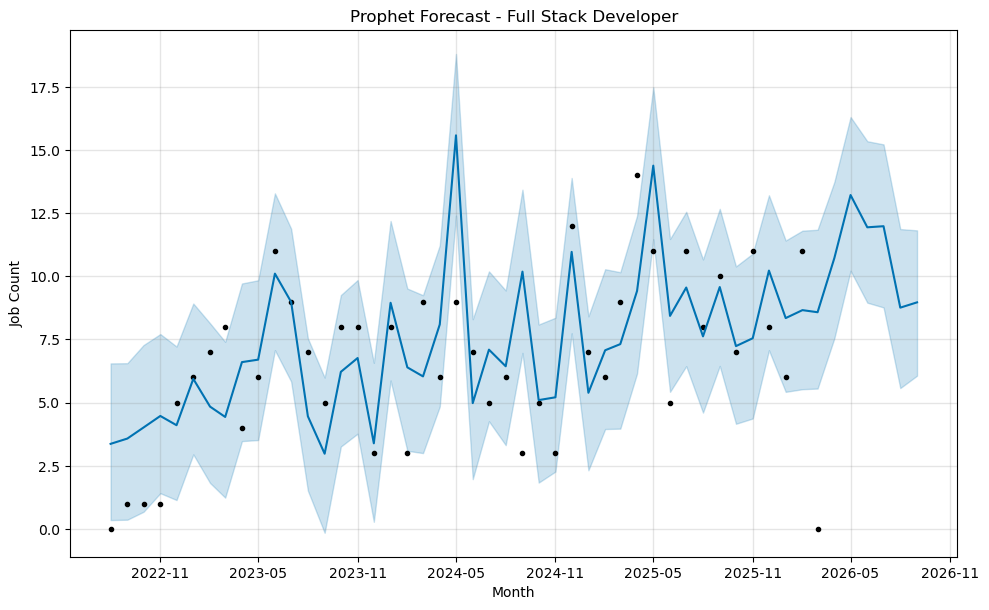

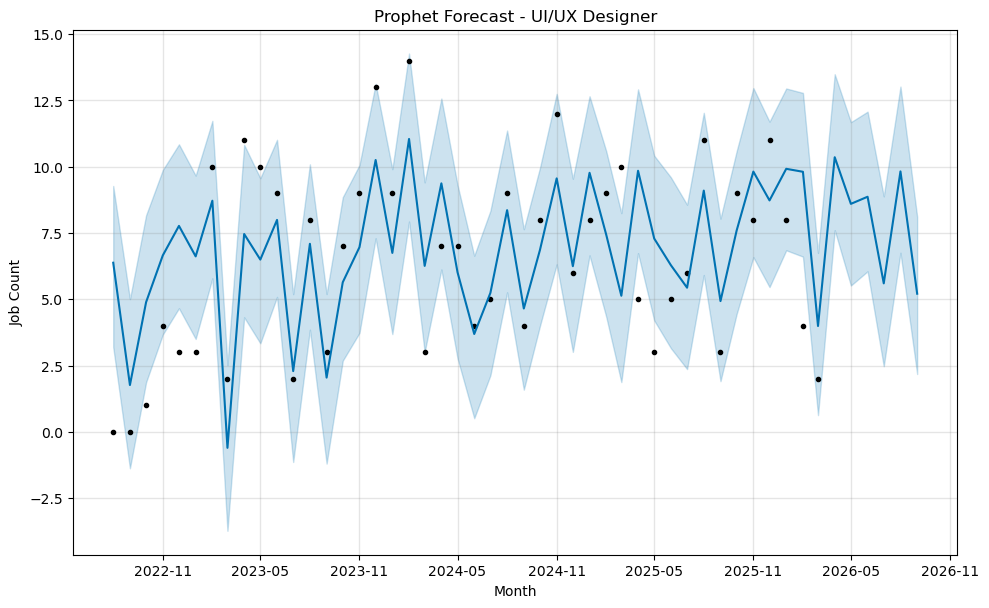

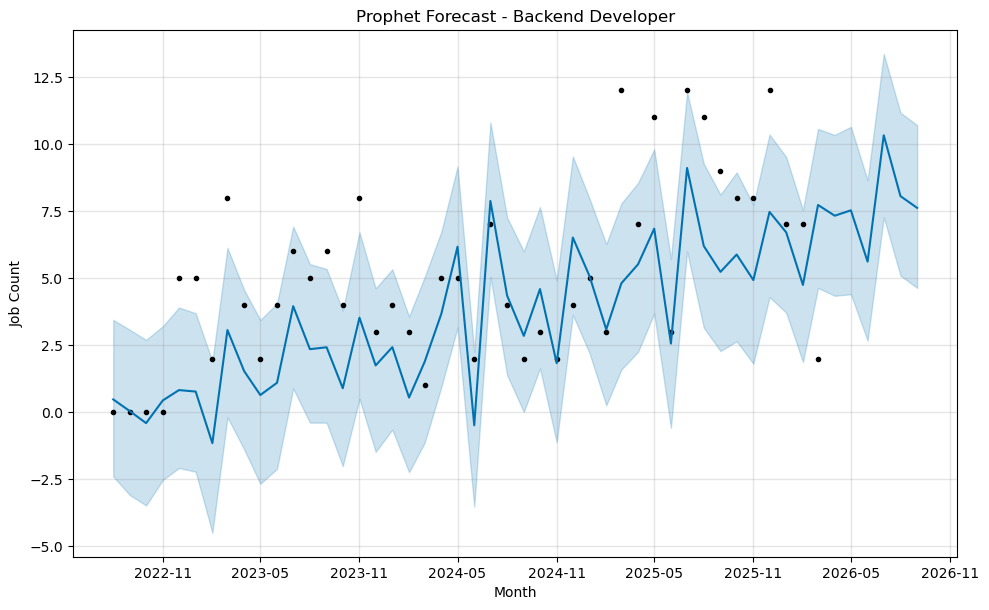

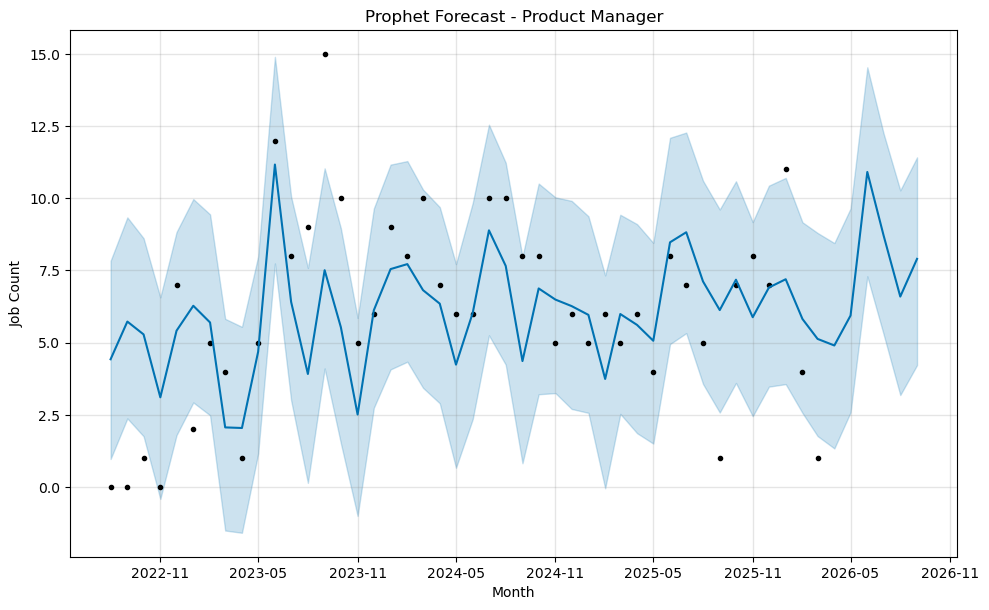

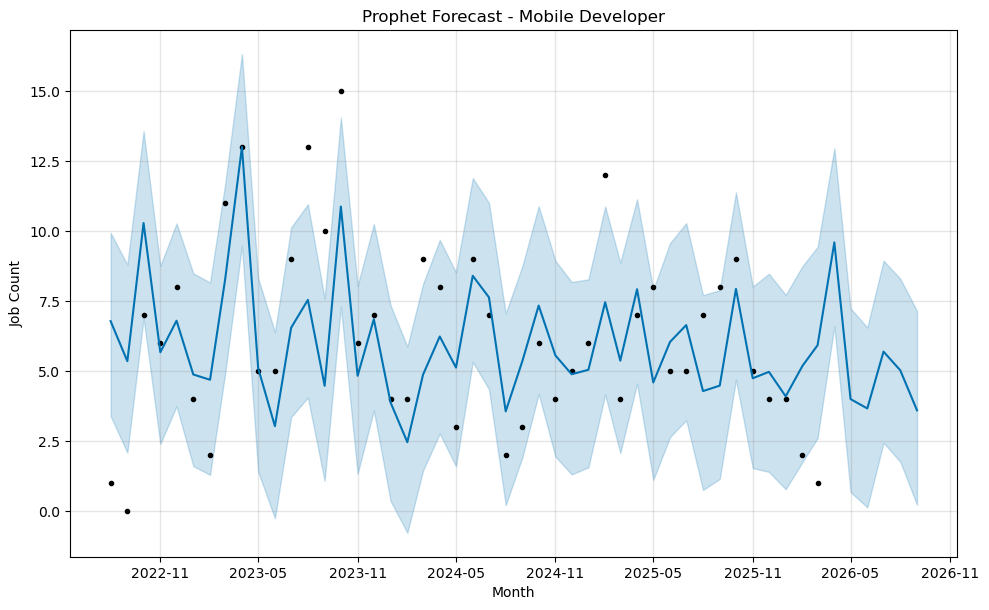

In [11]:
# Visualization: forecasts for top 5 predicted roles
plot_roles = predictions_df.head(5)['role'].tolist() if not predictions_df.empty else []

for role_name in plot_roles:
    model = prophet_models[role_name]
    fcst = prophet_forecasts[role_name]

    fig = model.plot(fcst)
    plt.title(f'Prophet Forecast - {role_name}')
    plt.xlabel('Month')
    plt.ylabel('Job Count')
    plt.show()

In [12]:
# Save artifacts
def slugify(value: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', str(value).lower()).strip('_')

for role_name, model in prophet_models.items():
    model_path = MODEL_DIR / f'prophet_{slugify(role_name)}.pkl'
    joblib.dump(model, model_path)

final_modeling_view.to_csv(OUTPUT_ROOT / 'modeling_dataset_month_role_job_count.csv', index=False)
evaluation_df.to_csv(METRIC_DIR / 'prophet_cv_metrics.csv', index=False)
predictions_df.to_csv(FORECAST_DIR / 'prophet_role_predictions.csv', index=False)

if prophet_forecasts:
    all_fcst = []
    for role_name, fcst in prophet_forecasts.items():
        temp = fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
        temp['role'] = role_name
        all_fcst.append(temp)
    pd.concat(all_fcst, ignore_index=True).to_csv(FORECAST_DIR / 'prophet_forecasts_all_roles.csv', index=False)

summary_payload = {
    'model': 'prophet',
    'top_role': top_role_prophet,
    'n_roles_trained': len(prophet_models)
}
with open(METRIC_DIR / 'prophet_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

print('Saved Prophet artifacts.')

Saved Prophet artifacts.


In [13]:
# Compare Prophet vs ARIMA metrics if ARIMA metrics exist
prophet_metrics_path = METRIC_DIR / 'prophet_cv_metrics.csv'
arima_metrics_path = METRIC_DIR / 'arima_cv_metrics.csv'

if prophet_metrics_path.exists() and arima_metrics_path.exists():
    p = pd.read_csv(prophet_metrics_path)
    a = pd.read_csv(arima_metrics_path)

    p_rmse_col = 'cv_rmse' if 'cv_rmse' in p.columns else ('rmse' if 'rmse' in p.columns else None)
    a_rmse_col = 'rmse' if 'rmse' in a.columns else None

    p_mean_rmse = p[p_rmse_col].dropna().mean() if p_rmse_col else np.nan
    a_mean_rmse = a[a_rmse_col].dropna().mean() if a_rmse_col else np.nan

    comparison = pd.DataFrame({
        'model': ['prophet', 'arima'],
        'mean_cv_rmse': [p_mean_rmse, a_mean_rmse]
    }).sort_values('mean_cv_rmse')

    display(comparison)
    best_model = comparison.iloc[0]['model']
    print(f'Best model by mean CV RMSE: {best_model}')
else:
    print('Run arima_pipeline.ipynb to enable side-by-side model comparison.')

,model,mean_cv_rmse
1,arima,1.930095
0,prophet,13.470040


Best model by mean CV RMSE: arima
